In [60]:
import pandas as pd
import numpy as np
import pypsa
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Configuration

In [61]:
data_dir = Path("../data")

mapping_pypsa_carriers = {
    "Combined-Cycle Gas": "Fossil Gas",
    "Load shedding": None,
    "Offshore Wind (AC)": "Wind Offshore",
    "Offshore Wind (DC)": "Wind Offshore",
    "Onshore Wind": "Wind Onshore",
    "Open-Cycle Gas": "Fossil Gas",
    "Run of River": "Hydro Run-of-river and poundage",
    "Solar": "Solar",
    "biomass": "Biomass",
    "nuclear": "Nuclear",
    "coal": "Fossil Hard coal",
    "lignite": "Fossil Brown coal/Lignite",
    "oil": "Fossil Oil",
    "solar-hsat": "Solar",
    "Pumped Hydro Storage": "Hydro Pumped Storage",
    "Reservoir & Dam": "Hydro Water Reservoir",
}


start_date = (pd.Timestamp("2022-01-01"),)
end_date = (pd.Timestamp("2022-12-31 23:00"),)


country = "ES"

resampling_rule = "W"

x_length = 6

phi = 1.618

data_dir = Path("../data")

n = pypsa.Network(data_dir / "network_files" / "hindcast-dyn-rolling-wy2022.nc")

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network '' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [62]:
# Color mapping for plotting

color_dict = n.carriers["color"].to_dict()

mapping_color = {
    "offwind-ac": "Wind Offshore",
    "offwind-dc": "Wind Offshore",
    "onwind": "Wind Onshore",
    "solar": "Solar",
    "solar-hsat": "Solar",
    "CCGT": "Fossil Gas",
    "OCGT": "Fossil Gas",
    "PHS": "Hydro Pumped Storage",
    "biomass": "Biomass",
    "coal": "Fossil Hard coal",
    "geothermal": "Geothermal",
    "hydro": "Hydro Water Reservoir",
    "lignite": "Fossil Brown coal/Lignite",
    "nuclear": "Nuclear",
    "oil": "Fossil Oil",
    "ror": "Hydro Run-of-river and poundage",
}

color_dict_new = {}

for original_name, new_name in mapping_color.items():
    # Use the color from the original carrier
    if original_name in color_dict:
        color_dict_new[new_name] = color_dict[original_name]


color_dict_new['Other'] = 'tab:red'
color_dict_new

{'Wind Offshore': '#74c6f2',
 'Wind Onshore': '#235ebc',
 'Solar': '#fdb915',
 'Fossil Gas': '#e0986c',
 'Hydro Pumped Storage': '#51dbcc',
 'Biomass': '#baa741',
 'Fossil Hard coal': '#545454',
 'Geothermal': '#ba91b1',
 'Hydro Water Reservoir': '#298c81',
 'Fossil Brown coal/Lignite': '#826837',
 'Nuclear': '#ff8c00',
 'Fossil Oil': '#c9c9c9',
 'Hydro Run-of-river and poundage': '#3dbfb0',
 'Other': 'tab:red'}

# PyPSA generation plot

In [63]:
supply_stats = n.statistics.supply(groupby=["bus", "carrier"], groupby_time=False) / 1000
country_supply = supply_stats.xs(country, level="bus")
country_generators_and_storage = country_supply.loc[["Generator", "StorageUnit"], :]
country_dispatch_raw = country_generators_and_storage.T.droplevel(0, axis=1)

ignored_carriers = [
    col for col, target in mapping_pypsa_carriers.items() if target is None and col in country_dispatch_raw.columns
]
country_dispatch_raw = country_dispatch_raw.drop(columns=ignored_carriers)

carrier_rename = {
    col: target
    for col, target in mapping_pypsa_carriers.items()
    if target is not None and col in country_dispatch_raw.columns
}
country_dispatch = country_dispatch_raw.rename(columns=carrier_rename)
country_dispatch = country_dispatch.T.groupby(level=0).sum().T  # merg


if resampling_rule:
    country_dispatch_res = country_dispatch.resample(resampling_rule).sum()
else:
    country_dispatch_res = country_dispatch

country_dispatch_res.head()

carrier,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,,
2022-01-02,15.069595,158.976124,177.432856,0.000017,0.000000,1.292316,0.000033,301.655397,179.154833,0.072464,136.605532
2022-01-09,52.743587,423.938356,621.015077,0.000227,29.033527,6.748963,697.255633,1055.793894,575.567309,0.307820,1235.362418
2022-01-16,52.743594,2520.495573,621.015113,1.117986,0.000051,8.599592,1.643883,1055.793907,678.051410,0.270922,611.684863
2022-01-23,52.743600,2927.520928,621.015147,1.680284,0.000000,4.533174,23.611620,1055.793917,706.039950,0.232522,425.076007
2022-01-30,52.743600,2127.158544,621.015147,0.000000,0.000000,4.195225,392.777952,1055.793917,695.401263,0.290926,516.106088


In [64]:
country_dispatch_res.index

DatetimeIndex(['2022-01-02', '2022-01-09', '2022-01-16', '2022-01-23',
               '2022-01-30', '2022-02-06', '2022-02-13', '2022-02-20',
               '2022-02-27', '2022-03-06', '2022-03-13', '2022-03-20',
               '2022-03-27', '2022-04-03', '2022-04-10', '2022-04-17',
               '2022-04-24', '2022-05-01', '2022-05-08', '2022-05-15',
               '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12',
               '2022-06-19', '2022-06-26', '2022-07-03', '2022-07-10',
               '2022-07-17', '2022-07-24', '2022-07-31', '2022-08-07',
               '2022-08-14', '2022-08-21', '2022-08-28', '2022-09-04',
               '2022-09-11', '2022-09-18', '2022-09-25', '2022-10-02',
               '2022-10-09', '2022-10-16', '2022-10-23', '2022-10-30',
               '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27',
               '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25',
               '2023-01-01'],
              dtype='datetime64[ns]', name='sna

In [65]:
country_dispatch.sum()

carrier
Biomass                             2750.201883
Fossil Gas                         43576.865489
Fossil Hard coal                   29424.152350
Fossil Oil                          1532.526163
Hydro Pumped Storage                2638.817833
Hydro Run-of-river and poundage      311.277205
Hydro Water Reservoir              15881.122674
Nuclear                            55052.111185
Solar                              37516.575901
Wind Offshore                         12.654848
Wind Onshore                       39787.823970
dtype: float64

# ENTSOE

In [66]:
entsoe_raw = pd.read_csv(
    data_dir / "generation" / f"generation_{country}_hourly_data.csv",
    index_col=0,
    parse_dates=True,
)

entsoe_filtered_raw = entsoe_raw[pd.Timestamp(start_date[0], tz="UTC") : pd.Timestamp(end_date[0], tz="UTC")]

entsoe_filtered_raw.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,Hydro Run-of-river and poundage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,Hydro Pumped Storage Net
2022-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+00:00,524.0,0.0,0.0,3557.0,842.0,112.0,0.0,0.0,0.0,1046.0,746.0,0.0,6092.0,50.0,96.0,75.0,265.0,0.0,6456.0,NaN
2022-01-01 02:00:00+00:00,532.0,0.0,0.0,3590.0,855.0,105.0,0.0,0.0,0.0,1045.0,733.0,0.0,6091.0,50.0,96.0,75.0,266.0,0.0,6144.0,NaN
2022-01-01 03:00:00+00:00,528.0,0.0,0.0,3444.0,868.0,105.0,0.0,0.0,0.0,1049.0,755.0,0.0,6091.0,51.0,98.0,75.0,260.0,0.0,5943.0,NaN
2022-01-01 04:00:00+00:00,533.0,0.0,0.0,3446.0,850.0,105.0,0.0,0.0,0.0,1031.0,719.0,0.0,6092.0,51.0,96.0,75.0,266.0,0.0,5836.0,NaN


In [67]:
entsoe_filtered_raw.columns

Index(['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas',
       'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale',
       'Fossil Peat', 'Geothermal', 'Hydro Run-of-river and poundage',
       'Hydro Water Reservoir', 'Marine', 'Nuclear', 'Other',
       'Other renewable', 'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore',
       'Hydro Pumped Storage Net'],
      dtype='str')

In [68]:
entsoe_filtered_raw.sum()

Biomass                             4046619.0
Fossil Brown coal/Lignite                 0.0
Fossil Coal-derived gas                   0.0
Fossil Gas                         77239045.5
Fossil Hard coal                    7913526.0
Fossil Oil                          1129562.5
Fossil Oil shale                          0.0
Fossil Peat                               0.0
Geothermal                                0.0
Hydro Run-of-river and poundage     6754687.5
Hydro Water Reservoir              15066483.0
Marine                                    0.0
Nuclear                            56155598.5
Other                                260759.0
Other renewable                      842824.0
Solar                              31089565.0
Waste                               2261273.5
Wind Offshore                             0.0
Wind Onshore                       58820837.5
Hydro Pumped Storage Net            -212978.0
dtype: float64

In [69]:

mapping_entsoe_pypsa = {
    "Biomass": "Biomass",
    "Fossil Brown coal/Lignite": "Fossil Brown coal/Lignite",
    "Fossil Coal-derived gas": "Fossil Hard coal",
    "Fossil Gas": "Fossil Gas",
    "Fossil Hard coal": "Fossil Hard coal",
    "Fossil Oil": "Fossil Oil",
    "Fossil Oil shale": "Fossil Oil",
    "Fossil Peat": "Fossil Brown coal/Lignite",
    "Geothermal": "Geothermal",
    "Hydro Pumped Storage": "Hydro Pumped Storage",
    "Hydro Run-of-river and poundage": "Hydro Run-of-river and poundage",
    "Hydro Water Reservoir": "Hydro Water Reservoir",
    "Marine": "Other",
    "Nuclear": "Nuclear",
    "Other": "Other",
    "Other renewable": "Other",
    "Solar": "Solar",
    "Waste": "Biomass",
    "Wind Offshore": "Wind Offshore",
    "Wind Onshore": "Wind Onshore",
}

entose_fitlered = entsoe_filtered_raw.rename(columns=mapping_entsoe_pypsa) 
entose_fitlered.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Hard coal,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil,Fossil Brown coal/Lignite,Geothermal,Hydro Run-of-river and poundage,Hydro Water Reservoir,Other,Nuclear,Other,Other,Solar,Biomass,Wind Offshore,Wind Onshore,Hydro Pumped Storage Net
2022-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+00:00,524.0,0.0,0.0,3557.0,842.0,112.0,0.0,0.0,0.0,1046.0,746.0,0.0,6092.0,50.0,96.0,75.0,265.0,0.0,6456.0,NaN
2022-01-01 02:00:00+00:00,532.0,0.0,0.0,3590.0,855.0,105.0,0.0,0.0,0.0,1045.0,733.0,0.0,6091.0,50.0,96.0,75.0,266.0,0.0,6144.0,NaN
2022-01-01 03:00:00+00:00,528.0,0.0,0.0,3444.0,868.0,105.0,0.0,0.0,0.0,1049.0,755.0,0.0,6091.0,51.0,98.0,75.0,260.0,0.0,5943.0,NaN
2022-01-01 04:00:00+00:00,533.0,0.0,0.0,3446.0,850.0,105.0,0.0,0.0,0.0,1031.0,719.0,0.0,6092.0,51.0,96.0,75.0,266.0,0.0,5836.0,NaN


In [70]:
entsoe_clean = entose_fitlered.T.groupby(level=0).sum().T
entsoe_clean.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage Net,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-01 01:00:00+00:00,789.0,0.0,3557.0,842.0,112.0,0.0,0.0,1046.0,746.0,6092.0,146.0,75.0,0.0,6456.0
2022-01-01 02:00:00+00:00,798.0,0.0,3590.0,855.0,105.0,0.0,0.0,1045.0,733.0,6091.0,146.0,75.0,0.0,6144.0
2022-01-01 03:00:00+00:00,788.0,0.0,3444.0,868.0,105.0,0.0,0.0,1049.0,755.0,6091.0,149.0,75.0,0.0,5943.0
2022-01-01 04:00:00+00:00,799.0,0.0,3446.0,850.0,105.0,0.0,0.0,1031.0,719.0,6092.0,147.0,75.0,0.0,5836.0


In [71]:
entsoe_clean['Hydro Pumped Storage Net'] = entsoe_clean['Hydro Pumped Storage Net'].clip(lower=0)
entsoe_clean = entsoe_clean.rename(columns={'Hydro Pumped Storage Net': 'Hydro Pumped Storage'}) / 1000     # to GWh
entsoe_clean

,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00+00:00,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
2022-01-01 01:00:00+00:00,0.789,0.0,3.557,0.842,0.112,0.0,0.000,1.046,0.746,6.092,0.146,0.075,0.0,6.456
2022-01-01 02:00:00+00:00,0.798,0.0,3.590,0.855,0.105,0.0,0.000,1.045,0.733,6.091,0.146,0.075,0.0,6.144
2022-01-01 03:00:00+00:00,0.788,0.0,3.444,0.868,0.105,0.0,0.000,1.049,0.755,6.091,0.149,0.075,0.0,5.943
2022-01-01 04:00:00+00:00,0.799,0.0,3.446,0.850,0.105,0.0,0.000,1.031,0.719,6.092,0.147,0.075,0.0,5.836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00+00:00,0.411,0.0,1.983,0.252,0.040,0.0,2.039,1.100,3.284,6.460,0.095,0.020,0.0,9.946
2022-12-31 20:00:00+00:00,0.404,0.0,2.253,0.258,0.040,0.0,0.943,1.061,3.091,6.462,0.091,0.020,0.0,9.583
2022-12-31 21:00:00+00:00,0.404,0.0,2.456,0.265,0.040,0.0,0.000,1.036,2.868,6.464,0.089,0.020,0.0,8.998
2022-12-31 22:00:00+00:00,0.401,0.0,2.596,0.248,0.040,0.0,0.000,1.034,2.596,6.464,0.092,0.020,0.0,7.677


In [72]:
entsoe_clean = entsoe_clean.tz_localize(None)
entsoe_clean.index

DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 01:00:00',
               '2022-01-01 02:00:00', '2022-01-01 03:00:00',
               '2022-01-01 04:00:00', '2022-01-01 05:00:00',
               '2022-01-01 06:00:00', '2022-01-01 07:00:00',
               '2022-01-01 08:00:00', '2022-01-01 09:00:00',
               ...
               '2022-12-31 14:00:00', '2022-12-31 15:00:00',
               '2022-12-31 16:00:00', '2022-12-31 17:00:00',
               '2022-12-31 18:00:00', '2022-12-31 19:00:00',
               '2022-12-31 20:00:00', '2022-12-31 21:00:00',
               '2022-12-31 22:00:00', '2022-12-31 23:00:00'],
              dtype='datetime64[us]', length=8760, freq=None)

In [73]:
entsoe_clean.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,0.000,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000
2022-01-01 01:00:00,0.789,0.0,3.557,0.842,0.112,0.0,0.0,1.046,0.746,6.092,0.146,0.075,0.0,6.456
2022-01-01 02:00:00,0.798,0.0,3.590,0.855,0.105,0.0,0.0,1.045,0.733,6.091,0.146,0.075,0.0,6.144
2022-01-01 03:00:00,0.788,0.0,3.444,0.868,0.105,0.0,0.0,1.049,0.755,6.091,0.149,0.075,0.0,5.943
2022-01-01 04:00:00,0.799,0.0,3.446,0.850,0.105,0.0,0.0,1.031,0.719,6.092,0.147,0.075,0.0,5.836


In [74]:
country_dispatch.head()

carrier,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Solar,Wind Offshore,Wind Onshore
snapshot,,,,,,,,,,,
2022-01-01 00:00:00,0.31395,4.837933,3.696518,3.900000e-07,0.0,0.023954,7.500000e-07,6.284487,0.0,0.002287,4.624681
2022-01-01 01:00:00,0.31395,0.766456,3.696518,3.800000e-07,0.0,0.023949,7.600000e-07,6.284487,0.0,0.002245,4.651885
2022-01-01 02:00:00,0.31395,0.000004,3.696518,3.100000e-07,0.0,0.023943,6.000000e-07,6.284487,0.0,0.002196,4.518802
2022-01-01 03:00:00,0.31395,0.000003,3.696518,3.000000e-07,0.0,0.023938,5.900000e-07,6.284487,0.0,0.002134,4.311908
2022-01-01 04:00:00,0.31395,0.000002,3.696518,3.000000e-07,0.0,0.023933,5.900000e-07,6.284487,0.0,0.002129,4.097910


In [75]:
unique_cols = list(dict.fromkeys(entsoe_clean.columns.tolist()))
clean_data = {col: entsoe_clean[[col]].sum(axis=1) for col in unique_cols}
entsoe_dedup = pd.DataFrame(clean_data, index=entsoe_clean.index)

diff = entsoe_dedup.copy()
for col in diff.columns:
    if col in country_dispatch.columns:
        diff[col] = entsoe_dedup[col] - country_dispatch[col]
    # else: leave as entsoe value untouched

diff.head()

,Biomass,Fossil Brown coal/Lignite,Fossil Gas,Fossil Hard coal,Fossil Oil,Geothermal,Hydro Pumped Storage,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other,Solar,Wind Offshore,Wind Onshore
2022-01-01 00:00:00,-0.31395,0.0,-4.837933,-3.696518,-3.900000e-07,0.0,0.0,-0.023954,-7.500000e-07,-6.284487,0.000,0.000,-0.002287,-4.624681
2022-01-01 01:00:00,0.47505,0.0,2.790544,-2.854518,1.119996e-01,0.0,0.0,1.022051,7.459992e-01,-0.192487,0.146,0.075,-0.002245,1.804115
2022-01-01 02:00:00,0.48405,0.0,3.589996,-2.841518,1.049997e-01,0.0,0.0,1.021057,7.329994e-01,-0.193487,0.146,0.075,-0.002196,1.625198
2022-01-01 03:00:00,0.47405,0.0,3.443997,-2.828518,1.049997e-01,0.0,0.0,1.025062,7.549994e-01,-0.193487,0.149,0.075,-0.002134,1.631092
2022-01-01 04:00:00,0.48505,0.0,3.445998,-2.846518,1.049997e-01,0.0,0.0,1.007067,7.189994e-01,-0.192487,0.147,0.075,-0.002129,1.738090


In [76]:
diff_res = diff.resample(resampling_rule).sum()

# Get prices

In [77]:
prices_dict = {}


sim_labels = {'hindcast-std',
              'hindcast-dyn',
              'hindcast-dyn-rolling'}
# Load simulation
for sim_label in sim_labels:
    file_dir = Path('../results_concat') / sim_label / 'electricity_prices' / "combined_electricity_prices.csv"

    df_sim = pd.read_csv(file_dir, index_col=0, parse_dates=True)
    df_sim = df_sim[df_sim.index.year.isin([2022])]

    prices_dict[sim_label] = df_sim

# Load benchmark
benchmark_path = data_dir / "benchmark" / "electricity_prices.csv"
df_bench = pd.read_csv(benchmark_path, index_col=0, parse_dates=True)

if df_bench.index.tz is None:
     df_bench.index = df_bench.index.tz_localize("UTC")
else:
    df_bench.index = df_bench.index.tz_convert("UTC")

df_bench = df_bench.interpolate().ffill().bfill()

df_bench = df_bench[df_bench.index.year.isin([2022])]

prices_dict["benchmark"] = df_bench
prices_dict

{'hindcast-dyn':                              AL          AT          BA          BE  \
 snapshot                                                              
 2022-01-01 00:00:00  164.710562  156.743834  156.359288  140.594888   
 2022-01-01 01:00:00  164.044772  156.743817  155.326374  135.257340   
 2022-01-01 02:00:00  160.889974  156.319970  154.661043  135.515949   
 2022-01-01 03:00:00  162.030591  156.168618  155.514276  136.505556   
 2022-01-01 04:00:00  162.458917  155.977500  155.305447  136.342516   
 ...                         ...         ...         ...         ...   
 2022-12-31 19:00:00  176.888374  173.741522  173.747036  160.907923   
 2022-12-31 20:00:00  173.835032  173.621355  173.353067  151.599910   
 2022-12-31 21:00:00  173.539161  173.657354  173.436281  151.599926   
 2022-12-31 22:00:00  173.534268  173.207571  172.289738  151.599796   
 2022-12-31 23:00:00  173.529857  172.588008  172.289721  151.599744   
 
                              BG          CH  

# That one plot

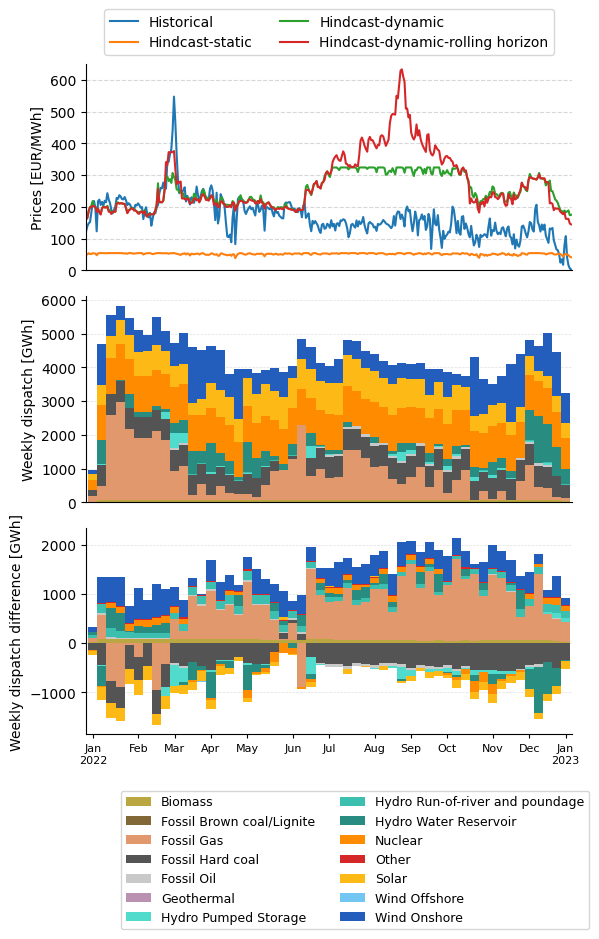

In [78]:
fig, axs = plt.subplots(
    ncols=1,
    nrows=3,
    figsize=(x_length, x_length * phi*0.8),
    sharex=False,
)

plot_order = [
    "benchmark",
    "hindcast-std",
    "hindcast-dyn",
    "hindcast-dyn-rolling",
]

for label in plot_order:
    if label not in prices_dict:
        continue
    df = prices_dict[label]

    if country not in df.columns:
        continue

    series = df[country]
    if resampling_rule:
        series = series.resample("D").mean()

    axs[0].plot(series, label=label, 
                #color=self.sim_color.get(label, None)
                )

legend_label_map = {
    "benchmark":            "Historical",
    "hindcast-std":         "Hindcast-static",
    "hindcast-dyn":         "Hindcast-dynamic",
    "hindcast-dyn-rolling": "Hindcast-dynamic-rolling horizon",
}
desired_order = ["benchmark", "hindcast-std", "hindcast-dyn", "hindcast-dyn-rolling"]
handles, labels = axs[0].get_legend_handles_labels()
handle_map      = dict(zip(labels, handles))
ordered_handles = [handle_map[k] for k in desired_order if k in handle_map]
ordered_labels  = [legend_label_map.get(k, k) for k in desired_order if k in handle_map]

axs[0].legend(ordered_handles, ordered_labels, frameon=True,
            loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.3), fancybox=True)
axs[0].set_xlim(left=start_date, right=end_date)
axs[0].set_ylim(bottom=0, top=650)
axs[0].set_ylabel("Prices [EUR/MWh]")
axs[0].grid(True, linestyle="dashed", alpha=0.5)
axs[0].set_xticks([])


country_dispatch_res.plot.bar(stacked=True, width=1.0, ax=axs[1], legend=False, color=color_dict_new)
axs[1].set_ylabel("Weekly dispatch [GWh]")
axs[1].set_xlabel("")
axs[1].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[1].set_axisbelow(True)
axs[1].xaxis.grid(False)
axs[1].set_xticks([])

# Reset to integer index for plotting, keep timestamps for tick labels
diff_res_plot = diff_res.copy()
diff_timestamps = diff_res_plot.index  # save for labels
diff_res_plot = diff_res_plot.reset_index(drop=True)  # integer index 0..52

diff_res_plot.plot.bar(stacked=True, width=1.0, ax=axs[2], legend=False, color=color_dict_new)
axs[2].set_xlabel("")
axs[2].set_ylabel("Weekly dispatch difference [GWh]")
axs[2].yaxis.grid(True, linestyle="dashed", linewidth=0.5, alpha=0.4, zorder=0)
axs[2].set_axisbelow(True)

# Monthly ticks
tick_positions = []
tick_labels = []
prev_month = None
for i, ts in enumerate(diff_timestamps):
    if ts.month != prev_month:
        tick_positions.append(i)
        tick_labels.append(ts.strftime("%b\n%Y") if (ts.month == 1 or prev_month is None) else ts.strftime("%b"))
        prev_month = ts.month

axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels, fontsize=8, rotation=0, ha="center")
axs[2].tick_params(axis='x', length=3)

# Remove top and right spines
for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend below figure
handles, labels = axs[2].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.6, -0.2),
    frameon=True,
    fontsize=9,
)

plt.tight_layout()
#plt.subplots_adjust(bottom=0.2)
plt.show()